# API Open Meteo

## Imports, settings and definitions

In [ ]:
pip install loguru -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 1.9 MB/s eta 0:00:00


In [ ]:
import requests
from loguru import logger
import json
import pandas as pd

In [ ]:
# Columns and Types

dtypes = {
    "latitude": float,
    "longitude": float,
    "city": str,
    "generationtime_ms": float,
    "utc_offset_seconds": int,
    "timezone": str,
    "timezone_abbreviation": str,
    "elevation": float,
    "hourly_units.time": str,
    "hourly_units.temperature_2m": str,
    "hourly_units.relative_humidity_2m": str,
    "hourly_units.precipitation": str,
    "hourly_units.soil_temperature_0cm": str,
    "hourly.time": object,
    "hourly.temperature_2m": object,
    "hourly.relative_humidity_2m": object,
    "hourly.precipitation": object,
    "hourly.soil_temperature_0cm": object
}

In [ ]:
# Cities to Analyze

cities = {
    "São Paulo": {"latitude": -23.55052, "longitude": -46.633308},
    "Rio de Janeiro": {"latitude": -22.906847, "longitude": -43.172896},
    "Belo Horizonte": {"latitude": -19.924502, "longitude": -43.935238},
    "Brasília": {"latitude": -15.793889, "longitude": -47.882778},
    "Curitiba": {"latitude": -25.427778, "longitude": -49.273056},
    "Salvador": {"latitude": -12.971111, "longitude": -38.510833},
    "Fortaleza": {"latitude": -3.71722, "longitude": -38.54306},
    "Recife": {"latitude": -8.04756, "longitude": -34.877},
    "Porto Alegre": {"latitude": -30.0277, "longitude": -51.2287},
    "Manaus": {"latitude": -3.119028, "longitude": -60.021731}
}

## API Class

In [ ]:
class OpenMeteo():

  def __init__(self, params):
    self.main_endpoint = "https://api.open-meteo.com/"
    self.params = params

  def make_request(self, url: str):

    logger.info(f'Fetching parcelas with params: {json.dumps(self.params, indent=4)}')

    response = requests.get(url, params=self.params, timeout=20)

    if response.status_code == 200:

      json_data = response.json()
      df = pd.json_normalize(json_data)

      logger.success("Dataframe built!")

      return df

    else:

      logger.error(f'Request failed with status code {response.status_code}: {response.reason}')
      return None


  def get_forecast(self):

    url = f'{self.main_endpoint}/v1/forecast'
    df = self.make_request(url)

    return df

## Bronze Dataframe

In [ ]:
df = pd.DataFrame({col: pd.Series(dtype=typ) for col, typ in dtypes.items()})

for city in cities.keys():

  logger.info(f'Fetching forecast for {city}')

  params = {
      "latitude": cities[city]["latitude"],
      "longitude": cities[city]["longitude"],
      "hourly": ["temperature_2m", "relative_humidity_2m", "precipitation", "soil_temperature_0cm"],
      "past_days": 90
  }

  api = OpenMeteo(params)

  df_api = api.get_forecast()
  df_api['city'] = city

  df = pd.concat([df, df_api])

bronze_df = df

2025-09-24 01:47:03.830 | INFO     | __main__:<cell line: 0>:5 - Fetching forecast for São Paulo
2025-09-24 01:47:03.832 | INFO     | __main__:make_request:9 - Fetching parcelas with params: {
    "latitude": -23.55052,
    "longitude": -46.633308,
    "hourly": [
        "temperature_2m",
        "relative_humidity_2m",
        "precipitation",
        "soil_temperature_0cm"
    ],
    "past_days": 90
}
2025-09-24 01:47:04.588 | SUCCESS  | __main__:make_request:18 - Dataframe built!
2025-09-24 01:47:04.593 | INFO     | __main__:<cell line: 0>:5 - Fetching forecast for Rio de Janeiro
2025-09-24 01:47:04.594 | INFO     | __main__:make_request:9 - Fetching parcelas with params: {
    "latitude": -22.906847,
    "longitude": -43.172896,
    "hourly": [
        "temperature_2m",
        "relative_humidity_2m",
        "precipitation",
        "soil_temperature_0cm"
    ],
    "past_days": 90
}
2025-09-24 01:47:05.339 | SUCCESS  | __main__:make_request:18 - Dataframe built!
2025-09-24 01:47

## Silver Dataframe

In [ ]:
hourly_cols = [
  'hourly.time',
  'hourly.temperature_2m',
  'hourly.relative_humidity_2m',
  'hourly.precipitation',
  'hourly.soil_temperature_0cm'
  ]

exploded_df = bronze_df.explode(hourly_cols)

exploded_df['hourly.time'] = pd.to_datetime(exploded_df['hourly.time'])

exploded_df['date'] = exploded_df['hourly.time'].dt.date

silver_df = exploded_df

## Gold Dataframe

In [ ]:
gold_df = (
  silver_df
  .groupby(['city', 'date'])
  .agg({
    'hourly.temperature_2m': 'mean',
    'hourly.relative_humidity_2m': 'mean',
    'hourly.precipitation': 'sum',
    'hourly.soil_temperature_0cm': 'mean'
  })
  .reset_index()
)

window = 7

gold_df[['temperature_2m_mm', 'humidity_mm', 'precipitation_mm', 'soil_temp_mm']] = (
    gold_df
    .sort_values(['city', 'date'])
    .groupby('city')[['hourly.temperature_2m',
                      'hourly.relative_humidity_2m',
                      'hourly.precipitation',
                      'hourly.soil_temperature_0cm']]
    .rolling(window, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

display(gold_df)

,city,date,hourly.temperature_2m,hourly.relative_humidity_2m,hourly.precipitation,hourly.soil_temperature_0cm,temperature_2m_mm,humidity_mm,precipitation_mm,soil_temp_mm
0,Belo Horizonte,2025-06-26,NaN,NaN,0,NaN,NaN,NaN,0.000000,NaN
1,Belo Horizonte,2025-06-27,NaN,NaN,0,NaN,NaN,NaN,0.000000,NaN
2,Belo Horizonte,2025-06-28,NaN,NaN,0,NaN,NaN,NaN,0.000000,NaN
3,Belo Horizonte,2025-06-29,NaN,NaN,0,NaN,NaN,NaN,0.000000,NaN
4,Belo Horizonte,2025-06-30,NaN,NaN,0,NaN,NaN,NaN,0.000000,NaN
...,...,...,...,...,...,...,...,...,...,...
965,São Paulo,2025-09-26,15.2,76.416667,0.0,16.266667,19.832738,73.815476,2.814286,20.563690
966,São Paulo,2025-09-27,16.054167,72.458333,0.0,17.229167,18.646429,74.916667,2.814286,19.319048
967,São Paulo,2025-09-28,17.908333,74.041667,0.0,18.491667,17.344643,78.351190,2.685714,18.055357
968,São Paulo,2025-09-29,19.979167,72.541667,0.0,20.241667,16.883929,77.809524,0.000000,17.638095


## Data Analysis

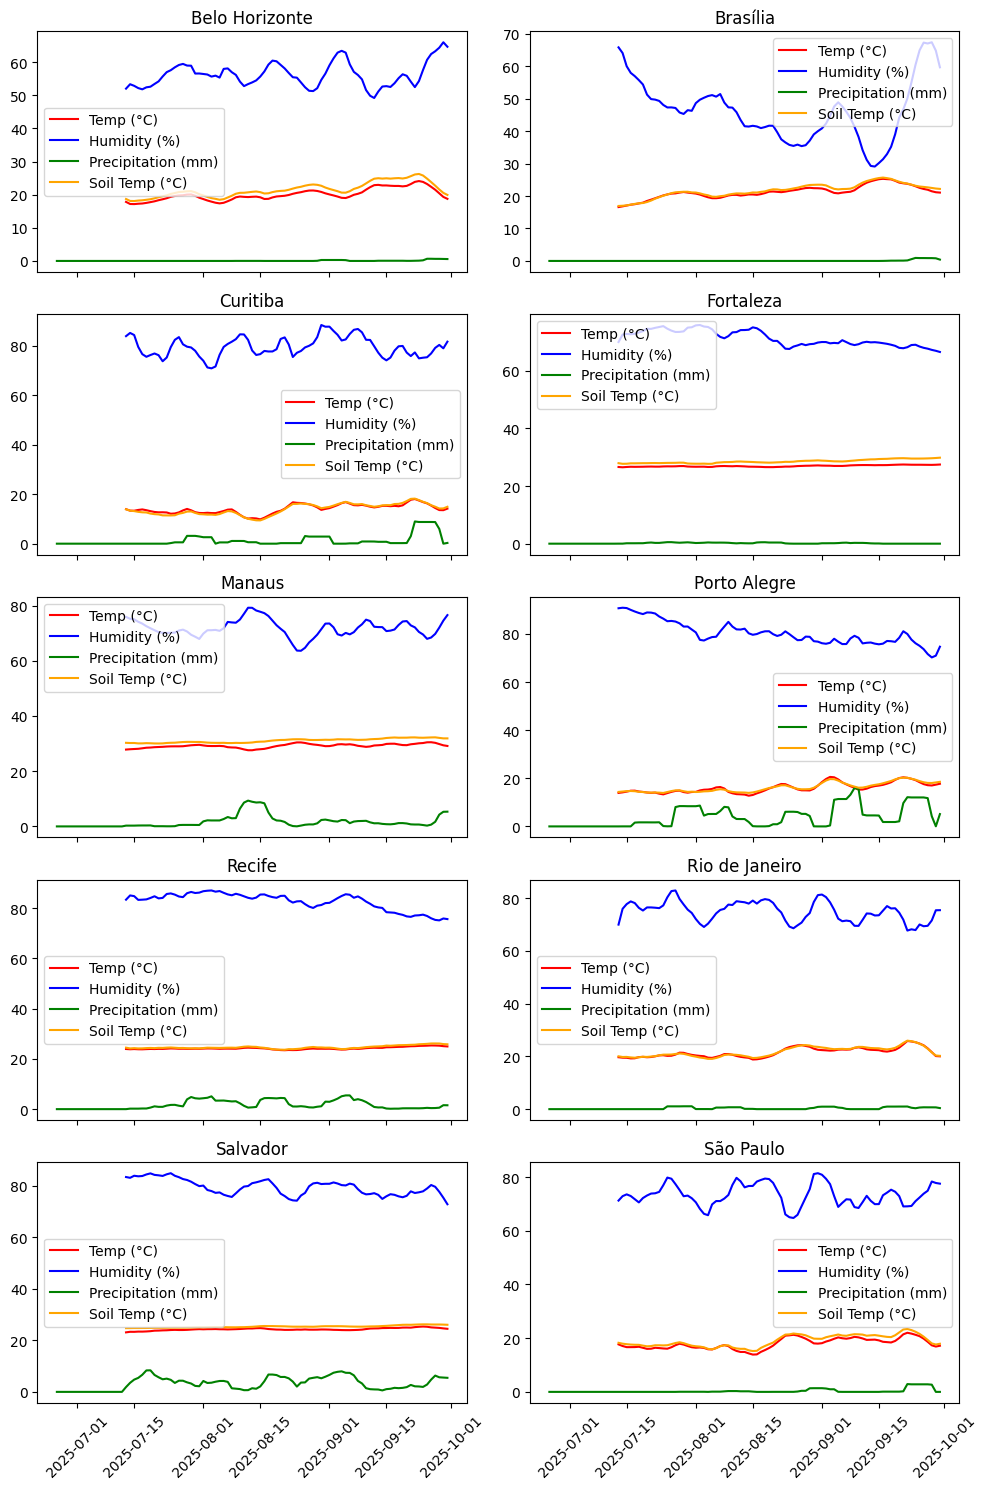

In [ ]:

cities = gold_df['city'].unique()

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(10, 15), sharex=True)

axes = axes.flatten()

for i, city in enumerate(cities):
    city_df = gold_df[gold_df['city'] == city]
    axes[i].plot(city_df['date'], city_df['temperature_2m_mm'], label='Temp (°C)', color='red')
    axes[i].plot(city_df['date'], city_df['humidity_mm'], label='Humidity (%)', color='blue')
    axes[i].plot(city_df['date'], city_df['precipitation_mm'], label='Precipitation (mm)', color='green')
    axes[i].plot(city_df['date'], city_df['soil_temp_mm'], label='Soil Temp (°C)', color='orange')
    axes[i].set_title(city)
    axes[i].legend()
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()